# Introducción

El presente trabajo se propone unificar en un mismo proyecto los dos grandes contenidos aprendidos en el curso de Data Science 3. Concretamente, una primera parte del trabajo consiste en efectuar un estudio de NLP sobre un dataset que contiene 1.130.017 reseñas de películas, extraído del sitio web "Rotten Tomatoes". En una segunda instancia, y a partir de la vectorización de los datos, se aplican una serie de modelos de predicción de clasificación multi-clase (postivo, negativo y neutro) aplicando algún modelo de Machine Learning y luego algunos modelos de Deep Learning de diferentes complejidades, para finalmente analizar los resultados obtenidos.

# Importación de librerías

In [9]:
!pip install nltk

In [10]:
import pandas as pd
import numpy as np
import nltk
from dataclasses import dataclass
import os
import gzip
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from fractions import Fraction
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import tensorflow as tf

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


# Upload de dataset y análisis preliminar

In [11]:
class Config ():
    path = "/content"
    file = "rotten_tomatoes_critic_reviews.csv"

In [12]:
config = Config()
config.path

'/content'

In [14]:
reviews = pd.read_csv(os.path.join(config.path, config.file))
reviews.head()

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...


In [15]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130017 entries, 0 to 1130016
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   rotten_tomatoes_link  1130017 non-null  object
 1   critic_name           1111488 non-null  object
 2   top_critic            1130017 non-null  bool  
 3   publisher_name        1130017 non-null  object
 4   review_type           1130017 non-null  object
 5   review_score          824081 non-null   object
 6   review_date           1130017 non-null  object
 7   review_content        1064211 non-null  object
dtypes: bool(1), object(7)
memory usage: 61.4+ MB


In [16]:
reviews.shape

(1130017, 8)

In [17]:
reviews= reviews.drop(columns=['rotten_tomatoes_link','critic_name','top_critic','publisher_name','review_type'])

In [18]:
reviews.head()

,review_score,review_date,review_content
0,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,NaN,2010-02-10,What's really lacking in The Lightning Thief i...


In [19]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130017 entries, 0 to 1130016
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   review_score    824081 non-null   object
 1   review_date     1130017 non-null  object
 2   review_content  1064211 non-null  object
dtypes: object(3)
memory usage: 25.9+ MB


In [20]:
reviews_clean=reviews.dropna()

In [21]:
reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 758709 entries, 3 to 1130016
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   review_score    758709 non-null  object
 1   review_date     758709 non-null  object
 2   review_content  758709 non-null  object
dtypes: object(3)
memory usage: 23.2+ MB


In [22]:
reviews_clean.head()

,review_score,review_date,review_content
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
6,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...
7,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ..."
8,B,2010-02-10,"Fun, brisk and imaginative"
9,3/5,2010-02-10,"Crammed with dragons, set-destroying fights an..."


In [23]:
scores = reviews_clean['review_score'].value_counts()

In [24]:
scores

,count
review_score,
3/5,76972
4/5,73702
3/4,69641
2/5,50130
2/4,45359
...,...
69/70,1
2.5/20,1
5.55/10,1


In [25]:
valores_unicos = reviews_clean['review_score'].dtypes
print(valores_unicos)

object


# Análisis Exploratorio de Datos

In [26]:
reviews_clean ["len"] = reviews_clean["review_content"].apply(len)

<ipython-input-26-7f5858765166>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_clean ["len"] = reviews_clean["review_content"].apply(len)


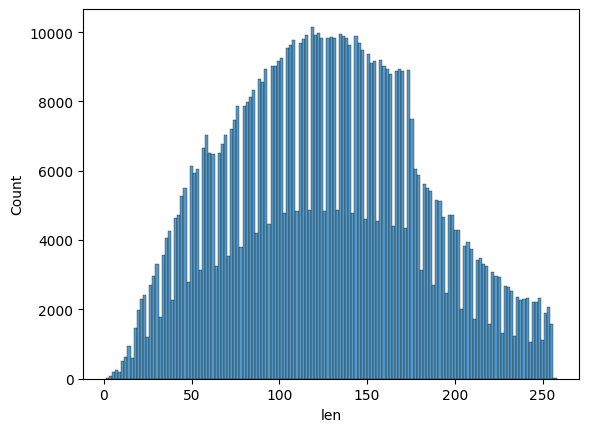

In [27]:
sns.histplot(reviews_clean["len"])
plt.show()

In [28]:
reviews_clean.sample()

,review_score,review_date,review_content,len
682128,2.5/4,2009-12-06,Despite accomplished special effects and a coo...,136


In [29]:
# creamos una función que convierte los puntajes en string a puntajes float
def fraction_to_decimal(fraction_string):
    try:
        numerator, denominator = map(float, fraction_string.split('/'))
        if denominator == 0: #denominador 0
            return None
        return numerator / denominator

    except ValueError:
        return None #errores


In [30]:
reviews_clean['review_score_decimal'] = reviews_clean['review_score'].apply(fraction_to_decimal)

<ipython-input-30-aee8086cfd55>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_clean['review_score_decimal'] = reviews_clean['review_score'].apply(fraction_to_decimal)


In [31]:
reviews_clean

,review_score,review_date,review_content,len,review_score_decimal
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...,213,0.70
6,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...,131,0.25
7,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ...",135,0.70
8,B,2010-02-10,"Fun, brisk and imaginative",26,NaN
9,3/5,2010-02-10,"Crammed with dragons, set-destroying fights an...",215,0.60
...,...,...,...,...,...
1130006,4/5,2017-07-10,As a spectacular war film with a powerful mora...,58,0.80
1130013,3.5/5,2007-03-07,"Seen today, it's not only a startling indictme...",121,0.70
1130014,B+,2010-09-16,A rousing visual spectacle that's a prequel of...,84,NaN
1130015,3.5/5,2011-02-28,"A simple two-act story: Prelude to war, and th...",251,0.70


In [32]:
reviews_clean = reviews_clean.dropna(subset=['review_score_decimal']) # elimina registros con puntaje A, B, C etc.

In [33]:
reviews_clean.shape #nos quedamos con un dataset de 634.209 registros

(634209, 5)

In [34]:
scr = reviews_clean['review_score_decimal'].value_counts()

In [35]:
scr

,count
review_score_decimal,
0.600000,85796
0.800000,84518
0.500000,72497
0.750000,71634
0.400000,54897
...,...
0.926000,1
0.985714,1
0.555000,1


In [36]:
def asignar_labels(label:int)->str:
    if label <= 0.4:
        return "negativo"
    elif label >= 0.7:
        return "positivo"
    else:
        return "neutral"

In [37]:
reviews_clean["score_cat"] = reviews_clean["review_score_decimal"].apply(asignar_labels)

<ipython-input-37-858b5a0e6998>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_clean["score_cat"] = reviews_clean["review_score_decimal"].apply(asignar_labels)


In [38]:
reviews_clean.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...,213,0.70,positivo
6,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...,131,0.25,negativo
7,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ...",135,0.70,positivo
9,3/5,2010-02-10,"Crammed with dragons, set-destroying fights an...",215,0.60,neutral
10,4/5,2010-02-10,"This action-packed fantasy adventure, based on...",210,0.80,positivo


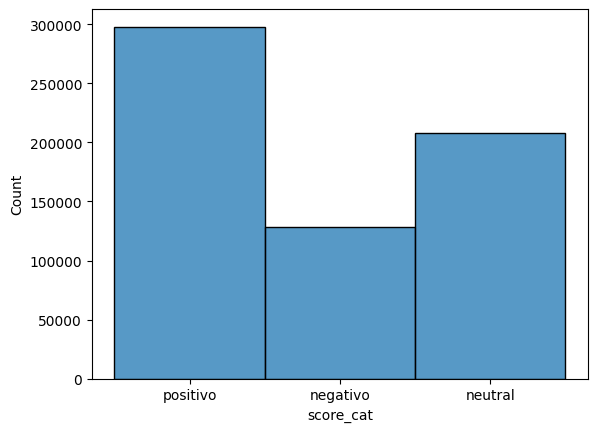

In [39]:
sns.histplot(reviews_clean["score_cat"])
plt.show()

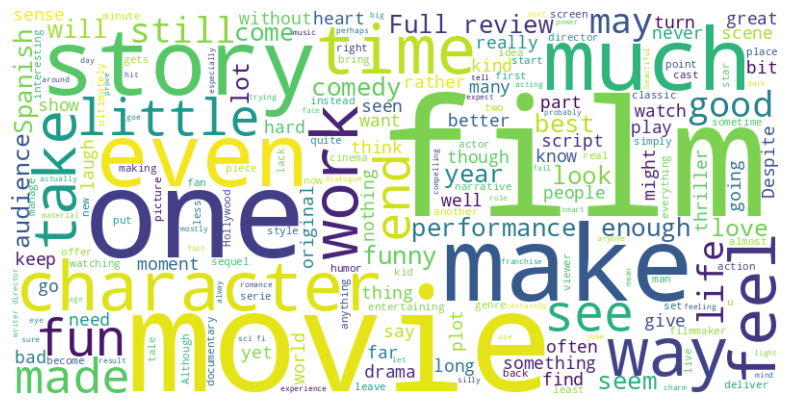

In [40]:
text = " ".join(review for review in reviews_clean['review_content'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Análisis de intensidad de sentimientos

In [41]:
sia = SentimentIntensityAnalyzer()
#creamos el objeto sia que instancia al método basado en el modelo VADER, que es capaz de interpretar el sentimiento contenido en el texto

In [42]:
reviews_clean ["compound_score"] = reviews_clean ["review_content"].apply(lambda review_content: sia.polarity_scores(review_content))

<ipython-input-42-91ce9bf77ce9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_clean ["compound_score"] = reviews_clean ["review_content"].apply(lambda review_content: sia.polarity_scores(review_content))


In [43]:
reviews_clean.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...,213,0.70,positivo,"{'neg': 0.08, 'neu': 0.727, 'pos': 0.193, 'com..."
6,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...,131,0.25,negativo,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
7,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ...",135,0.70,positivo,"{'neg': 0.079, 'neu': 0.661, 'pos': 0.261, 'co..."
9,3/5,2010-02-10,"Crammed with dragons, set-destroying fights an...",215,0.60,neutral,"{'neg': 0.08, 'neu': 0.769, 'pos': 0.151, 'com..."
10,4/5,2010-02-10,"This action-packed fantasy adventure, based on...",210,0.80,positivo,"{'neg': 0.0, 'neu': 0.767, 'pos': 0.233, 'comp..."


In [44]:
reviews_clean['compound_score'] = reviews_clean['compound_score'].apply(lambda x: x['compound'])
#nos quedamos con el puntaje obtenido en "compound"

<ipython-input-44-2740dc1b6c86>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_clean['compound_score'] = reviews_clean['compound_score'].apply(lambda x: x['compound'])


In [45]:
reviews_clean.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...,213,0.70,positivo,0.7050
6,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...,131,0.25,negativo,0.0000
7,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ...",135,0.70,positivo,0.7143
9,3/5,2010-02-10,"Crammed with dragons, set-destroying fights an...",215,0.60,neutral,0.3400
10,4/5,2010-02-10,"This action-packed fantasy adventure, based on...",210,0.80,positivo,0.8658


In [46]:
reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634209 entries, 3 to 1130015
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   review_score          634209 non-null  object 
 1   review_date           634209 non-null  object 
 2   review_content        634209 non-null  object 
 3   len                   634209 non-null  int64  
 4   review_score_decimal  634209 non-null  float64
 5   score_cat             634209 non-null  object 
 6   compound_score        634209 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 38.7+ MB


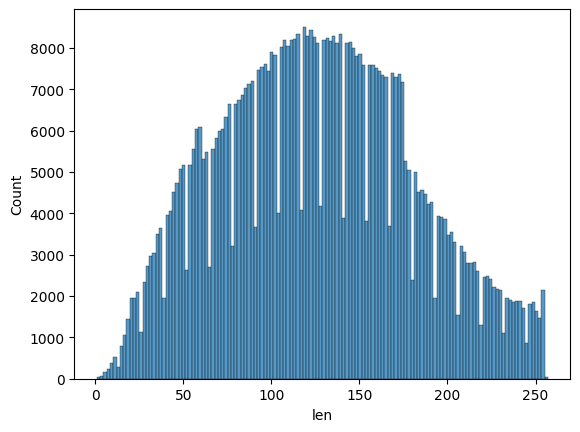

In [47]:
sns.histplot(reviews_clean["len"])
plt.show()

*Se observa en el atributo "len", que contiene el largo de las reseñas, una distribución normal.*

In [48]:
cs = reviews_clean['compound_score'].value_counts()

In [49]:
cs

,count
compound_score,
0.0000,79152
0.4404,11391
0.3612,9433
0.6369,8252
0.4019,7018
...,...
-0.7446,1
-0.8589,1
0.5459,1


In [50]:
def asignar_etiqueta(compound_score:float, limit_inf:float=-0.05, limit_sup:float=0.05):
    """_summary_

    Args:
        compound_score (_type_): _description_

    Returns:
        _type_: _description_
    """
    if compound_score >= limit_sup:
        return 'positivo'
    elif compound_score <= limit_inf:
        return 'negativo'
    else:
        return 'neutral'

In [51]:
reviews_clean['sentiment_label'] = reviews_clean['compound_score'].apply(asignar_etiqueta)

<ipython-input-51-948d974a750e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_clean['sentiment_label'] = reviews_clean['compound_score'].apply(asignar_etiqueta)


In [52]:
reviews_clean.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label
3,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...,213,0.70,positivo,0.7050,positivo
6,1/4,2010-02-10,Harry Potter knockoffs don't come more transpa...,131,0.25,negativo,0.0000,neutral
7,3.5/5,2010-02-10,"Percy Jackson isn't a great movie, but it's a ...",135,0.70,positivo,0.7143,positivo
9,3/5,2010-02-10,"Crammed with dragons, set-destroying fights an...",215,0.60,neutral,0.3400,positivo
10,4/5,2010-02-10,"This action-packed fantasy adventure, based on...",210,0.80,positivo,0.8658,positivo


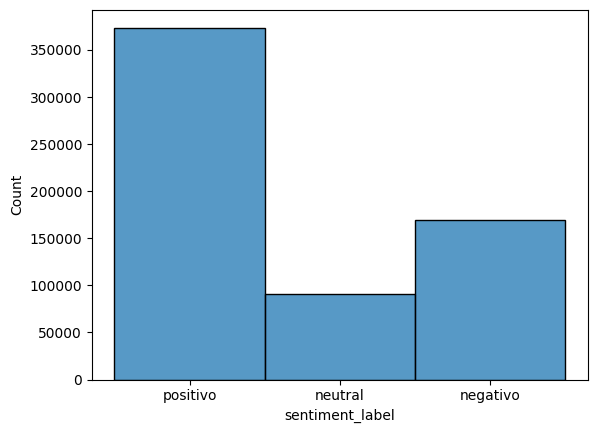

In [53]:
sns.histplot(reviews_clean["sentiment_label"])
plt.show()

## Resultados

In [54]:
print (classification_report(reviews_clean['score_cat'], reviews_clean['sentiment_label']))

              precision    recall  f1-score   support

    negativo       0.33      0.43      0.37    128248
     neutral       0.34      0.15      0.21    208148
    positivo       0.54      0.68      0.60    297813

    accuracy                           0.46    634209
   macro avg       0.40      0.42      0.40    634209
weighted avg       0.43      0.46      0.43    634209



# Modelado en spaCy

In [55]:
!pip install spacy

In [56]:
import spacy
from nltk.tokenize import word_tokenize

spacy.cli.download("en_core_web_sm")
#versión en inglés dado que las reviews estan en ese idioma

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [57]:
nlp = spacy.load("en_core_web_sm")

## Fraccionamiento de dataset

In [58]:
data = reviews_clean.sample(frac=0.2)
#a efectos didácticos se toma una fracción del dataset

In [59]:
data['entities'] = data['review_content'].apply(lambda x: [(ent.text, ent.label_) for ent in nlp(x).ents])
#extraigo las entidades y sus etiquetas

In [60]:
data.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label,entities
275146,3/4,2010-04-08,"Josh Klausner wrote the screenplay, but it rea...",249,0.75,positivo,0.8519,positivo,"[(Josh Klausner, PERSON), (Klausner, PERSON)]"
130540,3/10,2015-08-19,"Blood-splattered and ultra-violent, it's amazi...",89,0.30,negativo,-0.5095,negativo,[]
629468,3/4,2012-12-07,Tippet and Mims's achievement is to reveal tha...,185,0.75,positivo,0.0000,neutral,[]
111108,3/4,2011-03-18,"A nicely paced exercise, one that benefits fro...",110,0.75,positivo,0.8720,positivo,[]
735526,1/5,2003-02-23,This is when the Rocky series went from 'good'...,66,0.20,negativo,-0.5423,negativo,[]


In [61]:
def limpiar_texto(texto):
    #convierto a minusculas
    texto = texto.lower()
    #proceso con spicy y genero un objeto con tokens
    doc = nlp(texto)
    #filtra los stop words y une las lematizaciones
    texto_limpio = " ".join([token.lemma_ for token in doc if not token.is_stop])

    return texto_limpio

In [62]:
data['clean_text'] = data['review_content'].apply(limpiar_texto) #creo una columna con la cadena de lemas

In [63]:
data.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label,entities,clean_text
275146,3/4,2010-04-08,"Josh Klausner wrote the screenplay, but it rea...",249,0.75,positivo,0.8519,positivo,"[(Josh Klausner, PERSON), (Klausner, PERSON)]","josh klausner write screenplay , funniest line..."
130540,3/10,2015-08-19,"Blood-splattered and ultra-violent, it's amazi...",89,0.30,negativo,-0.5095,negativo,[],"blood - splatter ultra - violent , amazingly a..."
629468,3/4,2012-12-07,Tippet and Mims's achievement is to reveal tha...,185,0.75,positivo,0.0000,neutral,[],"tippet mim achievement reveal culture , subtly..."
111108,3/4,2011-03-18,"A nicely paced exercise, one that benefits fro...",110,0.75,positivo,0.8720,positivo,[],"nicely pace exercise , benefit sprinkling humo..."
735526,1/5,2003-02-23,This is when the Rocky series went from 'good'...,66,0.20,negativo,-0.5423,negativo,[],rocky series go ' good ' ' horrible crap . '


In [64]:
nltk.download('punkt')

data['tokens'] = data['clean_text'].apply(nltk.word_tokenize)
#convierte el texto limpio en tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [65]:
data.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label,entities,clean_text,tokens
275146,3/4,2010-04-08,"Josh Klausner wrote the screenplay, but it rea...",249,0.75,positivo,0.8519,positivo,"[(Josh Klausner, PERSON), (Klausner, PERSON)]","josh klausner write screenplay , funniest line...","[josh, klausner, write, screenplay, ,, funnies..."
130540,3/10,2015-08-19,"Blood-splattered and ultra-violent, it's amazi...",89,0.30,negativo,-0.5095,negativo,[],"blood - splatter ultra - violent , amazingly a...","[blood, -, splatter, ultra, -, violent, ,, ama..."
629468,3/4,2012-12-07,Tippet and Mims's achievement is to reveal tha...,185,0.75,positivo,0.0000,neutral,[],"tippet mim achievement reveal culture , subtly...","[tippet, mim, achievement, reveal, culture, ,,..."
111108,3/4,2011-03-18,"A nicely paced exercise, one that benefits fro...",110,0.75,positivo,0.8720,positivo,[],"nicely pace exercise , benefit sprinkling humo...","[nicely, pace, exercise, ,, benefit, sprinklin..."
735526,1/5,2003-02-23,This is when the Rocky series went from 'good'...,66,0.20,negativo,-0.5423,negativo,[],rocky series go ' good ' ' horrible crap . ',"[rocky, series, go, ', good, ', ', horrible, c..."


In [66]:
data['vector'] = data['clean_text'].apply(lambda x: nlp(x).vector)

In [67]:
data.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label,entities,clean_text,tokens,vector
275146,3/4,2010-04-08,"Josh Klausner wrote the screenplay, but it rea...",249,0.75,positivo,0.8519,positivo,"[(Josh Klausner, PERSON), (Klausner, PERSON)]","josh klausner write screenplay , funniest line...","[josh, klausner, write, screenplay, ,, funnies...","[-0.0023442507, -0.8557682, 0.47994575, -0.387..."
130540,3/10,2015-08-19,"Blood-splattered and ultra-violent, it's amazi...",89,0.30,negativo,-0.5095,negativo,[],"blood - splatter ultra - violent , amazingly a...","[blood, -, splatter, ultra, -, violent, ,, ama...","[-0.11586652, -0.37061945, 0.6409771, -0.47122..."
629468,3/4,2012-12-07,Tippet and Mims's achievement is to reveal tha...,185,0.75,positivo,0.0000,neutral,[],"tippet mim achievement reveal culture , subtly...","[tippet, mim, achievement, reveal, culture, ,,...","[-0.035875026, -0.7935408, 0.28029415, -0.2635..."
111108,3/4,2011-03-18,"A nicely paced exercise, one that benefits fro...",110,0.75,positivo,0.8720,positivo,[],"nicely pace exercise , benefit sprinkling humo...","[nicely, pace, exercise, ,, benefit, sprinklin...","[-0.1827331, -0.45427608, 0.25975692, -0.14030..."
735526,1/5,2003-02-23,This is when the Rocky series went from 'good'...,66,0.20,negativo,-0.5423,negativo,[],rocky series go ' good ' ' horrible crap . ',"[rocky, series, go, ', good, ', ', horrible, c...","[-0.40191805, -0.123802476, 0.20551537, 0.0232..."


In [68]:
vector_dim = data['vector'].apply(lambda x: len(x))
print(vector_dim.unique())

[96  0]


In [69]:
data ["len"] = data["vector"].apply(len)

In [70]:
data.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label,entities,clean_text,tokens,vector
275146,3/4,2010-04-08,"Josh Klausner wrote the screenplay, but it rea...",96,0.75,positivo,0.8519,positivo,"[(Josh Klausner, PERSON), (Klausner, PERSON)]","josh klausner write screenplay , funniest line...","[josh, klausner, write, screenplay, ,, funnies...","[-0.0023442507, -0.8557682, 0.47994575, -0.387..."
130540,3/10,2015-08-19,"Blood-splattered and ultra-violent, it's amazi...",96,0.30,negativo,-0.5095,negativo,[],"blood - splatter ultra - violent , amazingly a...","[blood, -, splatter, ultra, -, violent, ,, ama...","[-0.11586652, -0.37061945, 0.6409771, -0.47122..."
629468,3/4,2012-12-07,Tippet and Mims's achievement is to reveal tha...,96,0.75,positivo,0.0000,neutral,[],"tippet mim achievement reveal culture , subtly...","[tippet, mim, achievement, reveal, culture, ,,...","[-0.035875026, -0.7935408, 0.28029415, -0.2635..."
111108,3/4,2011-03-18,"A nicely paced exercise, one that benefits fro...",96,0.75,positivo,0.8720,positivo,[],"nicely pace exercise , benefit sprinkling humo...","[nicely, pace, exercise, ,, benefit, sprinklin...","[-0.1827331, -0.45427608, 0.25975692, -0.14030..."
735526,1/5,2003-02-23,This is when the Rocky series went from 'good'...,96,0.20,negativo,-0.5423,negativo,[],rocky series go ' good ' ' horrible crap . ',"[rocky, series, go, ', good, ', ', horrible, c...","[-0.40191805, -0.123802476, 0.20551537, 0.0232..."


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126842 entries, 275146 to 494047
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   review_score          126842 non-null  object 
 1   review_date           126842 non-null  object 
 2   review_content        126842 non-null  object 
 3   len                   126842 non-null  int64  
 4   review_score_decimal  126842 non-null  float64
 5   score_cat             126842 non-null  object 
 6   compound_score        126842 non-null  float64
 7   sentiment_label       126842 non-null  object 
 8   entities              126842 non-null  object 
 9   clean_text            126842 non-null  object 
 10  tokens                126842 non-null  object 
 11  vector                126842 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 12.6+ MB


# Pre-procesamiento para aplicación de modelos de predicción

In [72]:
label_encoder = LabelEncoder()
data['labels_encoded'] = label_encoder.fit_transform(data['score_cat'])
#se encodean las 3 categorías

In [73]:
check = data['labels_encoded'].unique()
print(check)

[2 0 1]


In [74]:
data.head()

,review_score,review_date,review_content,len,review_score_decimal,score_cat,compound_score,sentiment_label,entities,clean_text,tokens,vector,labels_encoded
275146,3/4,2010-04-08,"Josh Klausner wrote the screenplay, but it rea...",96,0.75,positivo,0.8519,positivo,"[(Josh Klausner, PERSON), (Klausner, PERSON)]","josh klausner write screenplay , funniest line...","[josh, klausner, write, screenplay, ,, funnies...","[-0.0023442507, -0.8557682, 0.47994575, -0.387...",2
130540,3/10,2015-08-19,"Blood-splattered and ultra-violent, it's amazi...",96,0.30,negativo,-0.5095,negativo,[],"blood - splatter ultra - violent , amazingly a...","[blood, -, splatter, ultra, -, violent, ,, ama...","[-0.11586652, -0.37061945, 0.6409771, -0.47122...",0
629468,3/4,2012-12-07,Tippet and Mims's achievement is to reveal tha...,96,0.75,positivo,0.0000,neutral,[],"tippet mim achievement reveal culture , subtly...","[tippet, mim, achievement, reveal, culture, ,,...","[-0.035875026, -0.7935408, 0.28029415, -0.2635...",2
111108,3/4,2011-03-18,"A nicely paced exercise, one that benefits fro...",96,0.75,positivo,0.8720,positivo,[],"nicely pace exercise , benefit sprinkling humo...","[nicely, pace, exercise, ,, benefit, sprinklin...","[-0.1827331, -0.45427608, 0.25975692, -0.14030...",2
735526,1/5,2003-02-23,This is when the Rocky series went from 'good'...,96,0.20,negativo,-0.5423,negativo,[],rocky series go ' good ' ' horrible crap . ',"[rocky, series, go, ', good, ', ', horrible, c...","[-0.40191805, -0.123802476, 0.20551537, 0.0232...",0


In [75]:
def vectors_to_np_array(vectors):
    # Convierte vectores en arrays
    array_vectors = [(np.array(vec), len(vec)) for vec in vectors]

    # Busca el vector más largo
    max_len = max(array_vectors, key=lambda x: x[1])[1]

    # "Paddea" vectores mas cortos para igualar la longitud
    padded_vectors = [np.pad(vec, (0, max_len - size), 'constant') for vec, size in array_vectors]

    # Crea el array
    return np.array(padded_vectors)

In [76]:
X = vectors_to_np_array(data['vector'].values)
y = data['labels_encoded'].values
#separamos las variables independienes de los labels

In [77]:
X.shape

(126842, 96)

In [78]:
y.shape

(126842,)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresión Logística

In [80]:

modelo1 = LogisticRegression(max_iter=1000)
modelo1.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [81]:
y_pred = modelo1.predict(X_test)

### Resultados

In [82]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.47313650518349165
              precision    recall  f1-score   support

           0       0.39      0.03      0.05      5163
           1       0.40      0.12      0.19      8348
           2       0.48      0.92      0.63     11858

    accuracy                           0.47     25369
   macro avg       0.42      0.35      0.29     25369
weighted avg       0.44      0.47      0.37     25369



# Red Neuronal Recurrente de 2 capas

In [83]:
model2 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(50, input_shape=(96,1)),
    tf.keras.layers.Dense(3, activation="softmax")
]) # 1 capa RNN simple y 1 capa densa

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [84]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model2.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [86]:
history = model2.fit(X_train, y_train,batch_size=32, epochs=6, validation_data=(X_test,y_test))

Epoch 1/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.4675 - loss: 1.0459 - val_accuracy: 0.4673 - val_loss: 1.0406
Epoch 2/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - accuracy: 0.4694 - loss: 1.0409 - val_accuracy: 0.4680 - val_loss: 1.0409
Epoch 3/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.4701 - loss: 1.0405 - val_accuracy: 0.4677 - val_loss: 1.0439
Epoch 4/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - accuracy: 0.4724 - loss: 1.0415 - val_accuracy: 0.4679 - val_loss: 1.0459
Epoch 5/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 83s 22ms/step - accuracy: 0.4675 - loss: 1.0475 - val_accuracy: 0.4674 - val_loss: 1.0451
Epoch 6/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.4684 - loss: 1.0446 - val_accuracy: 0.4674 - val_loss: 1.0472
Epoch 7/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 83s 22ms/step - accuracy: 0.4696 - loss: 1.0462 - val_accuracy: 0.4675 - val_loss: 1.0464
Epoch 8/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 75s 24ms/step - accuracy: 0.4724 -

## Resultados

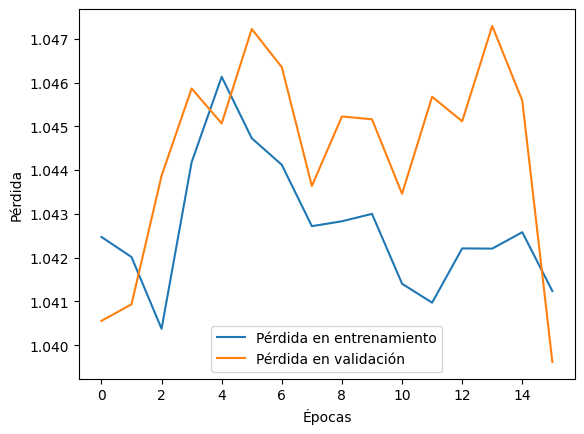

In [87]:
plt.plot(history.history['loss'], label='Pérdida en entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida en validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

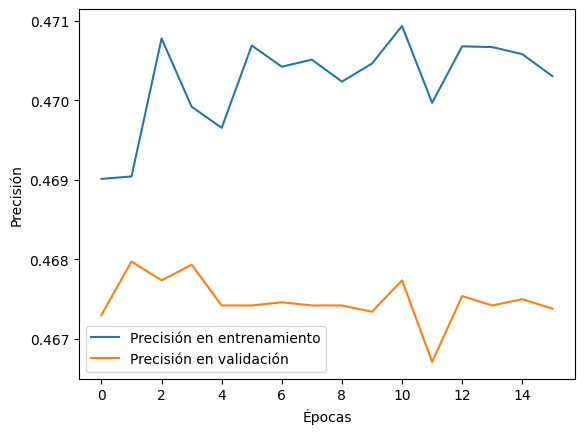

In [88]:
plt.plot(history.history['accuracy'], label='Precisión en entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión en validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Red Neuronal de 4 capas

In [89]:
model3 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(50, return_sequences=True, input_shape=(96, 1)),
    tf.keras.layers.SimpleRNN(30),
    tf.keras.layers.Dense(20, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
]) # 2 capas simples y 2 capas densas

In [90]:
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 96, 50)              │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 30)                  │           2,430 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              63 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,713 (22.32 KB)

 Trainable params: 5,713 (22.32 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model3.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [92]:
history_2 = model3.fit(X_train, y_train,batch_size=32, epochs=6, validation_data=(X_test,y_test))

Epoch 1/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 160s 49ms/step - accuracy: 0.4674 - loss: 1.0445 - val_accuracy: 0.4679 - val_loss: 1.0417
Epoch 2/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 220s 55ms/step - accuracy: 0.4708 - loss: 1.0423 - val_accuracy: 0.4674 - val_loss: 1.0454
Epoch 3/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 182s 49ms/step - accuracy: 0.4707 - loss: 1.0435 - val_accuracy: 0.4674 - val_loss: 1.0463
Epoch 4/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 204s 49ms/step - accuracy: 0.4724 - loss: 1.0422 - val_accuracy: 0.4674 - val_loss: 1.0459
Epoch 5/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 204s 50ms/step - accuracy: 0.4722 - loss: 1.0431 - val_accuracy: 0.4674 - val_loss: 1.0451
Epoch 6/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 200s 49ms/step - accuracy: 0.4711 - loss: 1.0426 - val_accuracy: 0.4674 - val_loss: 1.0459
Epoch 7/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 202s 49ms/step - accuracy: 0.4709 - loss: 1.0426 - val_accuracy: 0.4674 - val_loss: 1.0451
Epoch 8/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 203s 49ms/step - accuracy: 

## Resultados

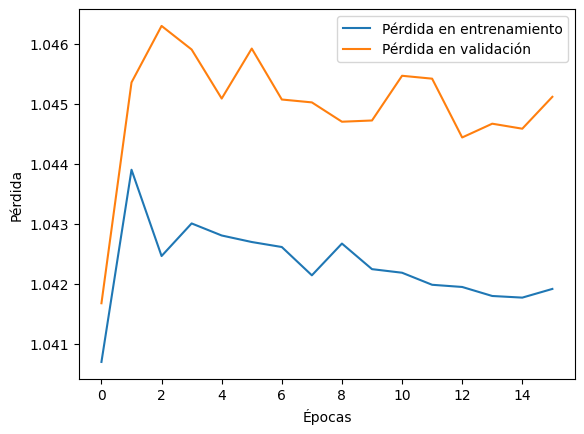

In [93]:
plt.plot(history_2.history['loss'], label='Pérdida en entrenamiento')
plt.plot(history_2.history['val_loss'], label='Pérdida en validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

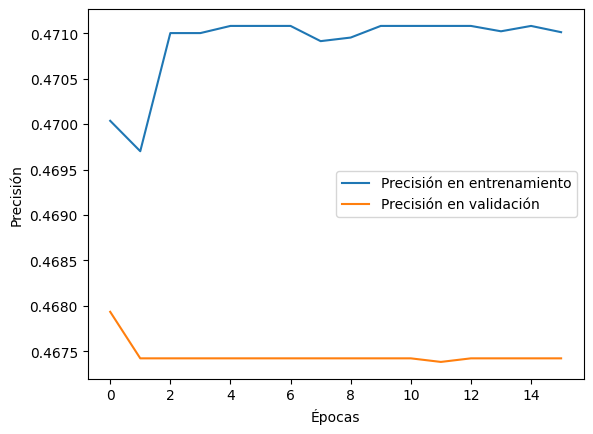

In [94]:
plt.plot(history_2.history['accuracy'], label='Precisión en entrenamiento')
plt.plot(history_2.history['val_accuracy'], label='Precisión en validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Red Neuronal de múltiples capas

In [95]:
model4 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(100, return_sequences=True, input_shape=(96, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.SimpleRNN(50,return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.SimpleRNN(30),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
]) # Aqui se incluyen capas de RNN, capas de dropout y capas densas o "fully connected"
   #con diferentes activaciones, buscando optimizar el modelo

In [96]:
model4.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [97]:
history_3 = model4.fit(X_train, y_train,batch_size=32, epochs=6, validation_data=(X_test,y_test))

Epoch 1/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 304s 94ms/step - accuracy: 0.4592 - loss: 1.0551 - val_accuracy: 0.4674 - val_loss: 1.0508
Epoch 2/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 323s 95ms/step - accuracy: 0.4682 - loss: 1.0470 - val_accuracy: 0.4674 - val_loss: 1.0458
Epoch 3/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 327s 96ms/step - accuracy: 0.4716 - loss: 1.0433 - val_accuracy: 0.4674 - val_loss: 1.0462
Epoch 4/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 302s 95ms/step - accuracy: 0.4703 - loss: 1.0446 - val_accuracy: 0.4674 - val_loss: 1.0452
Epoch 5/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 323s 96ms/step - accuracy: 0.4716 - loss: 1.0419 - val_accuracy: 0.4674 - val_loss: 1.0452
Epoch 6/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 325s 96ms/step - accuracy: 0.4709 - loss: 1.0435 - val_accuracy: 0.4674 - val_loss: 1.0450
Epoch 7/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 319s 96ms/step - accuracy: 0.4705 - loss: 1.0435 - val_accuracy: 0.4674 - val_loss: 1.0450
Epoch 8/16
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 325s 97ms/step - accuracy: 

## Resultados

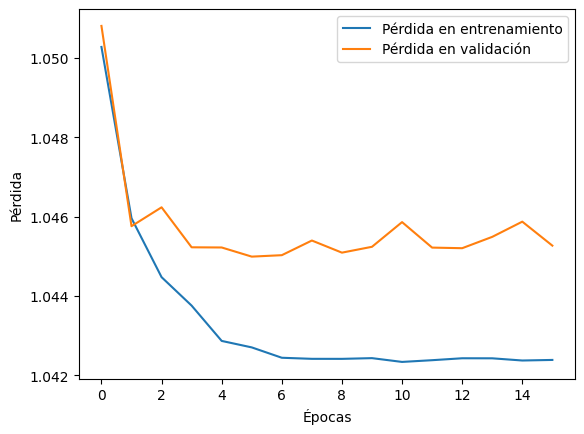

In [98]:
plt.plot(history_3.history['loss'], label='Pérdida en entrenamiento')
plt.plot(history_3.history['val_loss'], label='Pérdida en validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

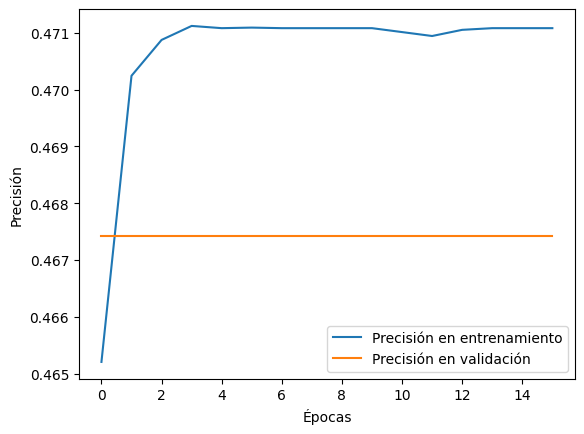

In [99]:
plt.plot(history_3.history['accuracy'], label='Precisión en entrenamiento')
plt.plot(history_3.history['val_accuracy'], label='Precisión en validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Conclusiones

Comparando los diferentes resultados obtenidos podemos decir que la performance no ha sido buena en ninguno de ellos, con accuracys en torno a 47%, pero sí es importante remarcar que el costo computacional y de tiempo es muy diferente entre los diferentes modelos entre sí, de forma que la complejización de los modelos no demostró mejorar la performance.
Dicho eso, podemos proponer una serie de indicaciones para continuar trabajando en busca de mejores resultados:
- Mejoras a nivel de manejo y manipulación de la base de datos, como por ejemplo en las funciones aplicadas para determinar las etiquetas y evaluar las calificaciones otorgadas por las reviews.
- Mejoras a nivel de hiperparámetros de las redes neuronales, como podría ser la función de pérdida, las funciones de activación, la cantidad de épocas y el batch size, por nombras algunas de las diferentes características que se pueden modificar.
- Probar diferentes arquitecturas, quizá insertando diferentes capas al modelo.